In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
import scopesim as sim
import scopesim_templates as sim_tp

py.warnings - WARNING: /Users/yashvi/Desktop/ZShooter/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



In [2]:
## Set up ZShooter

cmd = sim.UserCommands(use_instrument="ZShooter", set_modes=["SPEC"])
zs = sim.OpticalTrain(cmd)

wave = np.linspace(0.4, 1.5, 1001) * u.um
gal = sim_tp.extragalactic.galaxies.spiral_two_component(extent=200*u.arcsec, fluxes=(15, 15)*u.mag)
gal.shift(dy=-30*0.004)

zs.observe(gal, update=True)


py.warnings - WARNING: /Users/yashvi/Desktop/ZShooter/ScopeSim/scopesim/effects/spectral_trace_list.py:163: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()

py.warnings - WARNING: /Users/yashvi/Desktop/ZShooter/ScopeSim/scopesim/effects/spectral_trace_list.py:205: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

py.warnings - WARNING: /Users/yashvi/Desktop/ZShooter/ScopeSim/scopesim/effects/spectral_trace_list.py:205: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()



 FOV effects: 100%|██████████| 3/3 [00:11<00:00,  3.70s/it]

astar.scopesim.optics.image_plane - No BUNIT found in added HDU.



 FOV effects:  33%|███▎      | 1/3 [00:01<00:02,  1.07s/it]

astar.scopesim.effects.spectral_trace_list_utils - WARNING: map_spectra_to_focal_plane: 3057811 negative pixels


...


 FOV effects:  33%|███▎      | 1/3 [00:01<00:02,  1.06s/it]

astar.scopesim.effects.spectral_trace_list_utils - WARNING: map_spectra_to_focal_plane: 4418418 negative pixels



 FOV effects: 100%|██████████| 3/3 [00:13<00:00,  4.46s/it]

astar.scopesim.optics.image_plane - No BUNIT found in added HDU.



 FOVs: 100%|██████████| 3/3 [00:36<00:00, 12.03s/it]


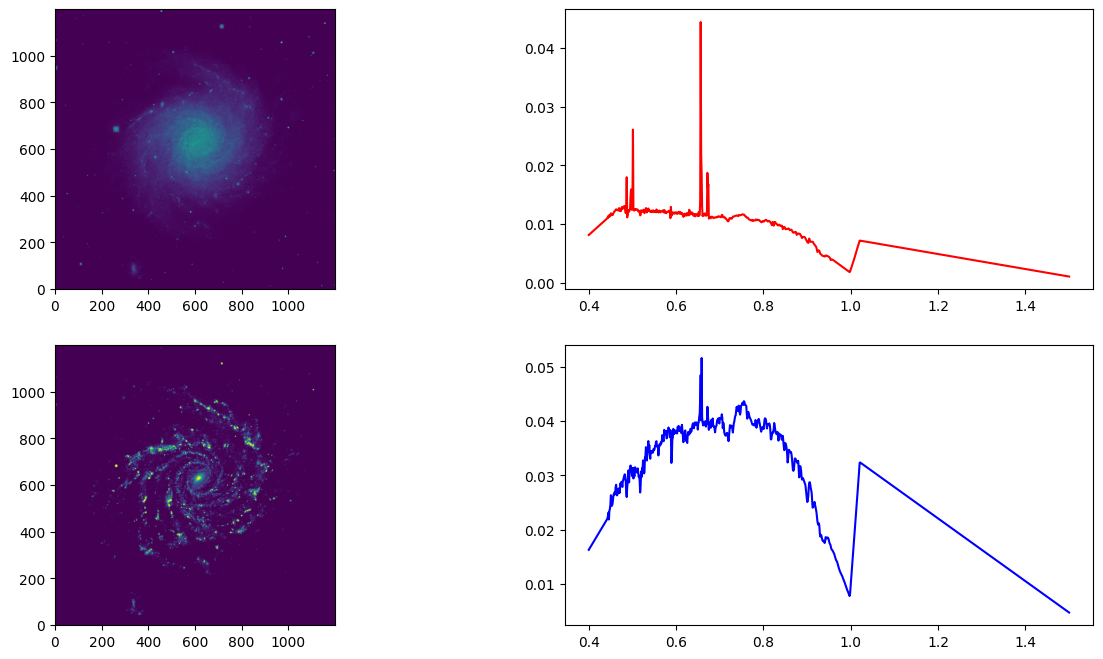

In [3]:
plt.figure(figsize=(15,8))
for i, c in zip([0, 1], "rb"):
    plt.subplot(2,2,2*i+1)
    plt.imshow(gal.fields[i].data, origin="lower")
    plt.subplot(2,2,2*i+2)
    plt.plot(wave, gal.spectra[i](wave), c=c)

astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


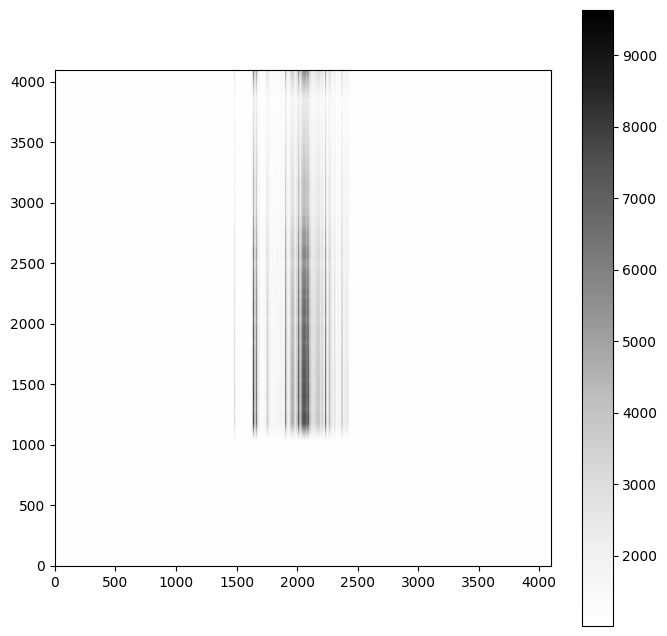

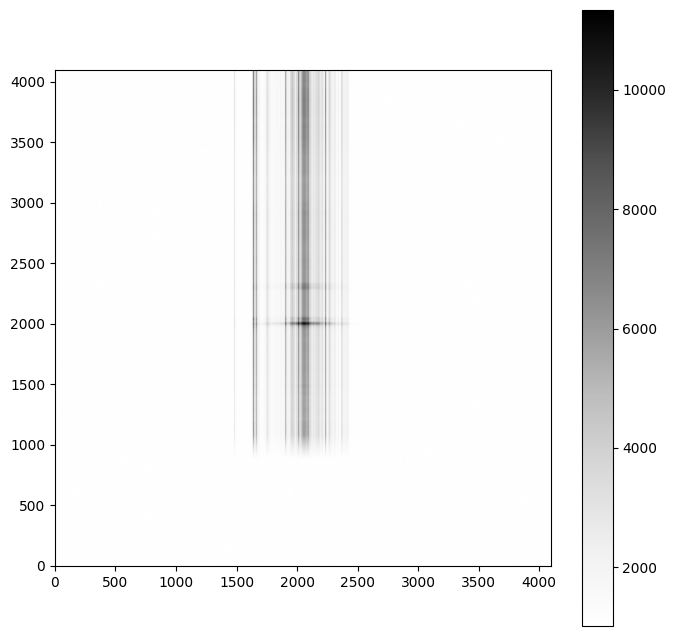

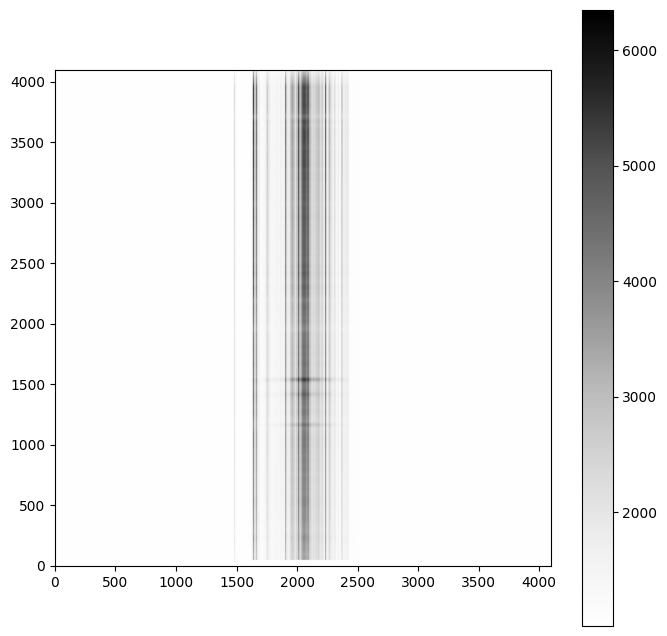

In [4]:
hdus = zs.readout()
for hdu in hdus:
    plt.figure(figsize=(8,8))
    plt.imshow(hdu[1].data, origin="lower", cmap="Grays")
    plt.colorbar()

In [5]:
from astropy.io import fits
hdu = fits.open('../irdb/ZShooter/traces/TRACE_ZSHOOTER.fits')
hdu[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
ECAT    =                    1                                                  
EDATA   =                    2                                                  
AUTHOR  = 'David Jones'                                                         
SOURCE  = 'David Jones'                                                         
DESCRIPT= 'R2500I OSIRIS LSS Spectral Trace'                                    
DATE-CRE= '2022-04-08'                                                          
DATE-MOD= '2023-05-31'                                                          
DATE    = '2023-05-31'                                                          
HISTORY 2023-05-31 : (OC) ad

In [6]:
hdu[1].data

FITS_rec([('TRACE_R2500I', 2, 0, 0), ('TRACE_R2500R', 3, 1, 1),
          ('TRACE_R2500V', 4, 2, 2)],
         dtype=(numpy.record, [('description', 'S12'), ('extension_id', '>i8'), ('aperture_id', '>i8'), ('image_plane_id', '>i8')]))

In [7]:
hdu[2].data

FITS_rec([(0.73572911, -254.        , -30.        , -30.72      ),
          (0.74979606, -254.        , -30.        , -27.48631579),
          (0.76396595, -254.        , -30.        , -24.25263158),
          (0.77823878, -254.        , -30.        , -21.01894737),
          (0.79261455, -254.        , -30.        , -17.78526316),
          (0.80709327, -254.        , -30.        , -14.55157895),
          (0.82167493, -254.        , -30.        , -11.31789474),
          (0.83635953, -254.        , -30.        ,  -8.08421053),
          (0.85114708, -254.        , -30.        ,  -4.85052632),
          (0.86603757, -254.        , -30.        ,  -1.61684211),
          (0.881031  , -254.        , -30.        ,   1.61684211),
          (0.89612737, -254.        , -30.        ,   4.85052632),
          (0.91132669, -254.        , -30.        ,   8.08421053),
          (0.92662894, -254.        , -30.        ,  11.31789474),
          (0.94203415, -254.        , -30.        ,  14.551578

In [8]:
hdu[3].data

FITS_rec([(0.55989152, -254.        , -30.        , -30.72      ),
          (0.57023277, -254.        , -30.        , -27.48631579),
          (0.58067302, -254.        , -30.        , -24.25263158),
          (0.59121227, -254.        , -30.        , -21.01894737),
          (0.60185051, -254.        , -30.        , -17.78526316),
          (0.61258774, -254.        , -30.        , -14.55157895),
          (0.62342397, -254.        , -30.        , -11.31789474),
          (0.63435919, -254.        , -30.        ,  -8.08421053),
          (0.64539341, -254.        , -30.        ,  -4.85052632),
          (0.65652662, -254.        , -30.        ,  -1.61684211),
          (0.66775882, -254.        , -30.        ,   1.61684211),
          (0.67909002, -254.        , -30.        ,   4.85052632),
          (0.69052022, -254.        , -30.        ,   8.08421053),
          (0.70204941, -254.        , -30.        ,  11.31789474),
          (0.71367759, -254.        , -30.        ,  14.551578

In [9]:
hdu[4].data

FITS_rec([(0.44484262, -254.        , -30.        , -30.72      ),
          (0.4528932 , -254.        , -30.        , -27.48631579),
          (0.46101019, -254.        , -30.        , -24.25263158),
          (0.4691936 , -254.        , -30.        , -21.01894737),
          (0.47744343, -254.        , -30.        , -17.78526316),
          (0.48575967, -254.        , -30.        , -14.55157895),
          (0.49414233, -254.        , -30.        , -11.31789474),
          (0.50259141, -254.        , -30.        ,  -8.08421053),
          (0.5111069 , -254.        , -30.        ,  -4.85052632),
          (0.51968881, -254.        , -30.        ,  -1.61684211),
          (0.52833714, -254.        , -30.        ,   1.61684211),
          (0.53705188, -254.        , -30.        ,   4.85052632),
          (0.54583304, -254.        , -30.        ,   8.08421053),
          (0.55468061, -254.        , -30.        ,  11.31789474),
          (0.5635946 , -254.        , -30.        ,  14.551578